# Project B – Not Even Magic can hide Social Graphs

##  Research Question

Do **Hogwarts Houses** truly capture the real **Social Communities** in the Harry Potter universe, or is the social structure better explained by other forms of **affiliation** such as **narrative roles**, **family ties**, **friendships**, **organizations** (for example the **Death Eaters**, the **Order of the Phoenix**), **Hogwarts staff groups**, and major plot-aligned clusters?

In the books, characters are sorted into houses as if this defines identity and relationships. However, characters frequently interact across house boundaries through friendships, mentorships, alliances, family connections, and shared missions. This raises the central question: Are houses an actual structure of community, or just a symbolic framework placed on top of a more complex social reality?

## Motivation

Hogwarts Houses are portrayed as a core part of identity. They influence loyalty, competition, personality traits, and self-concept. Yet the narrative shows many interactions that challenge the idea that house is the defining social unit. Consider a few examples:

- **Voldemort** is a **Slytherin**, but **Death Eater networks** form through **ideology** and **family** rather than **house**.  
- **Hermione** and **Snape** interact primarily as **student and teacher**, not as **Gryffindor vs Slytherin** members.  
- **Dumbledore’s Army** is a **cross-house resistance group** including **Gryffindors**, **Hufflepuffs**, and **Ravenclaws**.  
- The **Order of the Phoenix** unites people from **diverse backgrounds** rather than a **single school identity**.

These examples illustrate that the social fabric of the wizarding world is layered. Houses are visible, but do they meaningfully reflect how characters cluster socially? Or are connections better explained by narrative purpose, shared goals, family networks, and conflict alignment?

## Goal

The aim of this project is to use learnings from this course to uncover the actual community structure of the Harry Potter universe and compare it directly with the official **Hogwarts House divisions**.

The study will:

1. Build a character co-occurrence network from the entire book series.  
2. Apply community detection methods such as **Louvain** to identify natural clusters.  
3. Examine whether alternative structures explain clustering more strongly.  
3. Analyse the results to understand whether houses reflect meaningful social organization or if the true networks are driven by plot roles, affiliations, and interpersonal ties.

The goal is to empirically test whether Hogwarts Houses reflect real Community Structure or whether they function more as a narrative conceit overshadowed by deeper social alignments throughout the story.


## Imports

We import all **required libraries** for **data handling**, **visualization**, **NLP feature extraction**,  
**network construction**, and **community detection**.

**Libraries used:**

- **`pandas`** for data loading and preprocessing  
- **`numpy`** for numerical operations  
- **`matplotlib` & `seaborn`** for plotting  
- **`networkx`** for graph construction  
- **`sklearn`** (**TF-IDF + cosine similarity**) for NLP similarity  
- **`community_louvain`** for **Louvain community detection**  
- **`wordcloud`** (optional) for visualizing **community keywords**  

Below is the code to import everything and set **plotting defaults**.


In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import community.community_louvain as community_louvain

from wordcloud import WordCloud

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
sns.set_palette("deep")

print("All libraries imported successfully!")


All libraries imported successfully!


## Load Dataset

We load the cleaned character dataset (`characters_unique.csv`) containing:

- **Name**: Character names  
- **House**: Hogwarts house  
- **Groups**: Other groups such as Death Eaters, Order of the Phoenix, Dumbledore's Army, or family networks  
- **Description**: Text descriptions extracted from the books (used for NLP analysis)

### How the Dataset Was Created

1. **Source**: The initial character list was taken from **Muggle’s Guide to Harry Potter**.  
2. **Initial Size**: The raw dataset contained **398 characters**.  
3. **Cleaning**: Many **duplicates and alternative name spellings** were merged to create unique entries.  
4. **Annotation**: Houses, known affiliations, and family relationships were manually annotated based on canonical sources (books, wikis).  
5. **Final Dataset**: After cleaning, we have **260 unique characters**, each with house, group memberships, and description text. This ensures both structured and textual data are available for **network analysis** and **NLP tasks**.

In [28]:
df = pd.read_csv("characters_unique.csv")

df.head()
print("Shape:", df.shape)
print("Columns:", list(df.columns[:4]))

Shape: (260, 14)
Columns: ['Name', 'House', 'Groups', 'Description']


## Exploratory Data Analysis (EDA)

Before performing NLP and network construction, we conduct a brief exploratory data analysis (EDA) to understand the dataset and ensure its quality.

The EDA includes:

- Count **total characters**: Verify the number of unique characters (260 after cleaning) to confirm completeness.  
- **House distribution**: Check how characters are distributed across Gryffindor, Slytherin, Hufflepuff, Ravenclaw, and those with no house assigned.  
- **Missing description values**: Identify characters with empty or missing descriptions, since NLP feature extraction requires textual data.  
- Show a few description samples to review text content and ensure cleaning was successful.

These checks help confirm **dataset quality** and ensure the data is suitable for our analysis.

In [29]:
print("Total characters:", df.shape[0])
print("Columns:", df.columns[:4].tolist())   # first 4 columns only


Total characters: 260
Columns: ['Name', 'House', 'Groups', 'Description']


In [30]:
print("House Counts:")
print(df["House"].value_counts(dropna=False))


House Counts:
House
NaN           89
Slytherin     72
Gryffindor    53
Ravenclaw     23
Hufflepuff    23
Name: count, dtype: int64


In [31]:
missing_desc = df["Description"].isna().sum()
print("Missing Descriptions:", missing_desc)


Missing Descriptions: 0


In [32]:
for i in range(5):
    row = df.iloc[i]

    name = row["Name"]
    house = row.get("House", "")
    groups = row.get("Groups", "")
    description = str(row.get("Description", ""))[:200].replace("\n", " ")

    print(f"Character: {name}")
    print(f"House: {house}")
    print(f"Groups: {groups}")
    print(f"Description: {description}")
    print("---\n")


Character: Harry Potter
House: Gryffindor
Groups: Dumbledores Army; Gryffindor Quidditch Team; Order of the Phoenix allied; Ministry of Magic later
Description: Main protagonist who survived Voldemorts attack and fought against him
---

Character: Ron Weasley
House: Gryffindor
Groups: Dumbledores Army; Gryffindor Quidditch Team; Order of the Phoenix allied; Weasley family
Description: Harrys loyal friend known for bravery and support in the war
---

Character: Hermione Granger
House: Gryffindor
Groups: Dumbledores Army; SPEW; Ministry of Magic later; Order of the Phoenix allied
Description: Very intelligent witch top student and key strategist against Voldemort
---

Character: Professor Binns
House: nan
Groups: Hogwarts Staff History of Magic Professor
Description: Ghost teacher who teaches History of Magic known for dull lectures
---

Character: Charity Burbage
House: nan
Groups: Hogwarts Staff Muggle Studies Professor
Description: Professor who supported Muggle rights and was killed 

## Preprocessing

We prepare the dataset for **NLP analysis** and **network construction** to ensure that all features are clean, consistent, and usable.

The preprocessing steps include:

- **Fill missing descriptions**: Any characters with empty or missing description text are filled with a placeholder (e.g., empty string or short note) so that **TF-IDF computation** can proceed without errors.  
- **Normalize groups (optional)**: To standardize the group/affiliation information, we:
  - Convert all entries to **lowercase**  
  - Split **comma-separated strings** into individual group labels  
  - Strip **extra whitespace** from each entry  
  - Remove **empty entries** to avoid meaningless labels  

Proper preprocessing ensures that the **network and NLP analyses** are reliable, and that the resulting **communities** are interpretable in terms of **both text similarity and narrative roles**.


In [33]:

# 1. Fill missing descriptions and ensure string type
df["Description"] = df["Description"].fillna("").astype(str)

# 2. Normalize groups (optional)
if "Groups" in df.columns:
    def normalize_groups(x):
        if pd.isna(x):
            return []
        # lowercase → split by comma → strip spaces → remove empties
        parts = [g.strip().lower() for g in str(x).split(",")]
        return [g for g in parts if g]

    df["Groups"] = df["Groups"].apply(normalize_groups)

print("Preprocessing complete.")
df[["Name", "House", "Groups", "Description"]].head()


Preprocessing complete.


,Name,House,Groups,Description
0,Harry Potter,Gryffindor,[dumbledores army; gryffindor quidditch team; ...,Main protagonist who survived Voldemorts attac...
1,Ron Weasley,Gryffindor,[dumbledores army; gryffindor quidditch team; ...,Harrys loyal friend known for bravery and supp...
2,Hermione Granger,Gryffindor,[dumbledores army; spew; ministry of magic lat...,Very intelligent witch top student and key str...
3,Professor Binns,NaN,[hogwarts staff history of magic professor],Ghost teacher who teaches History of Magic kno...
4,Charity Burbage,NaN,[hogwarts staff muggle studies professor],Professor who supported Muggle rights and was ...


## BUILD MAIN SOCIAL NETWORK

The code constructs the **main social network** of Harry Potter characters by connecting characters who share **common group affiliations**, such as the Order of the Phoenix, Death Eaters, Dumbledore’s Army, or family networks. Each character is represented as a **node** with metadata including their **house** and list of **groups**. **Edges** are created between characters who share one or more groups, and the **edge weight reflects the number of shared groups**, indicating the strength of their connection. This results in a **weighted social network** that captures how characters are linked through overlapping affiliations. The network can then be used for **community detection**, visualization, and analyzing whether Hogwarts Houses or other narrative structures correspond to actual social clusters in the wizarding world.




In [34]:
G = nx.Graph()

for idx, row in df.iterrows():
    G.add_node(
        row["Name"],
        house=row["House"],
        groups=row["Groups"]
    )

# Add edges: characters share one or more groups
for i in range(len(df)):
    for j in range(i+1, len(df)):
        g1 = df.iloc[i]["Groups"]
        g2 = df.iloc[j]["Groups"]

        # Convert to sets for safety
        if isinstance(g1, str):
            g1 = eval(g1)
        if isinstance(g2, str):
            g2 = eval(g2)

        shared = set(g1).intersection(set(g2))

        if len(shared) > 0:
            G.add_edge(df.iloc[i]["Name"], df.iloc[j]["Name"], weight=len(shared))

print("Main Social Network Built.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Main Social Network Built.
Nodes: 260
Edges: 390


This code below builds the **main social network** of Harry Potter characters based on **shared group affiliations**. Each character is added as a **node** with attributes like **house** and **groups**, and **edges** are created between characters who share one or more groups, with **weights** representing the number of shared affiliations. After constructing the graph, `nx.spring_layout` is used to compute positions for nodes for **visualization**, preparing the network for plotting or further analysis.

The below code builds the social network in the same way as the one in Cell no 8, with nodes representing characters and edges connecting those who share group affiliations, weighted by the number of shared groups. The key difference is the addition of `nx.spring_layout`, which computes positions for the nodes to enable **visualization** of the network, whereas the previous version only constructed the graph without preparing it for plotting.



In [35]:

G = nx.Graph()

for idx, row in df.iterrows():
    G.add_node(row["Name"], house=row["House"], groups=row["Groups"])

for i in range(len(df)):
    for j in range(i+1, len(df)):
        g1 = df.iloc[i]["Groups"]
        g2 = df.iloc[j]["Groups"]

        if isinstance(g1, str): g1 = eval(g1)
        if isinstance(g2, str): g2 = eval(g2)

        shared = set(g1).intersection(set(g2))
        if len(shared) > 0:
            G.add_edge(df.iloc[i]["Name"], df.iloc[j]["Name"], weight=len(shared))

print("Main Social Graph Built:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

pos = nx.spring_layout(G, seed=42)


Main Social Graph Built: 260 nodes, 390 edges


## TF-IDF Vectorization

We now begin the NLP part of the analysis.

TF-IDF (Term Frequency–Inverse Document Frequency) converts each character’s **Description**  
into a **numerical vector**, where important / distinctive words get higher weights and  
very common words get lower weights.  
These vectors allow us to compute **semantic similarity** between characters later using cosine similarity.

We limit the vocabulary size (`max_features=3000`) to keep the model efficient and focused on relevant words.

This code converts the character **descriptions** into a **TF-IDF matrix** for NLP analysis. First, it extracts all description texts into a **corpus**. Then, it creates a `TfidfVectorizer` that removes common English stop words and limits the vocabulary to **3000 features** for efficiency. The `fit_transform` method computes the TF-IDF vectors for all characters, resulting in a **matrix where each row represents a character** and each column represents a weighted word feature. This matrix can be used to calculate **semantic similarity** between characters or as input for network construction and community detection.



In [36]:
corpus = df["Description"].tolist()


tfidf = TfidfVectorizer(stop_words="english", max_features=3000)


tfidf_matrix = tfidf.fit_transform(corpus)


tfidf_matrix[0].toarray()

print("TF-IDF matrix shape:", tfidf_matrix.shape)

tfidf_matrix


TF-IDF matrix shape: (260, 645)


<260x645 sparse matrix of type '<class 'numpy.float64'>'
	with 1502 stored elements in Compressed Sparse Row format>

## Cosine Similarity Matrix

After obtaining the **TF-IDF vectors** for each character, we compute the **cosine similarity** between every pair of characters. Cosine similarity is a measure of how similar two vectors are in terms of their direction, which in this context reflects how **similar the descriptions of two characters are**. A higher cosine similarity indicates that characters are described using more similar words, suggesting potential **semantic or narrative connections**.

To better understand the distribution of similarity values, we **plot a histogram of the scores**. This helps identify the range of typical similarities and informs the selection of a **threshold** for adding edges in the character network. Typically, an edge threshold between **0.12 and 0.18** is chosen, meaning that only pairs of characters with a similarity above this value will be connected in the network. This approach ensures that the network captures **meaningful relationships** without becoming too dense or noisy.


This code computes the **cosine similarity matrix** for all character TF-IDF vectors, which quantifies how similar each pair of character descriptions is. It then extracts the **upper triangular values** (excluding the diagonal) to focus on unique pairs and calculates the **mean and median similarity** for reference. A histogram of the similarity scores is plotted to visualize the distribution, with vertical lines marking the mean and median. Additionally, a shaded band highlights a **suggested edge threshold range (0.12–0.18)**, which indicates the similarity values above which characters will be connected in the network. This visualization helps determine a **reasonable threshold** for building a meaningful, not overly dense, character similarity network.


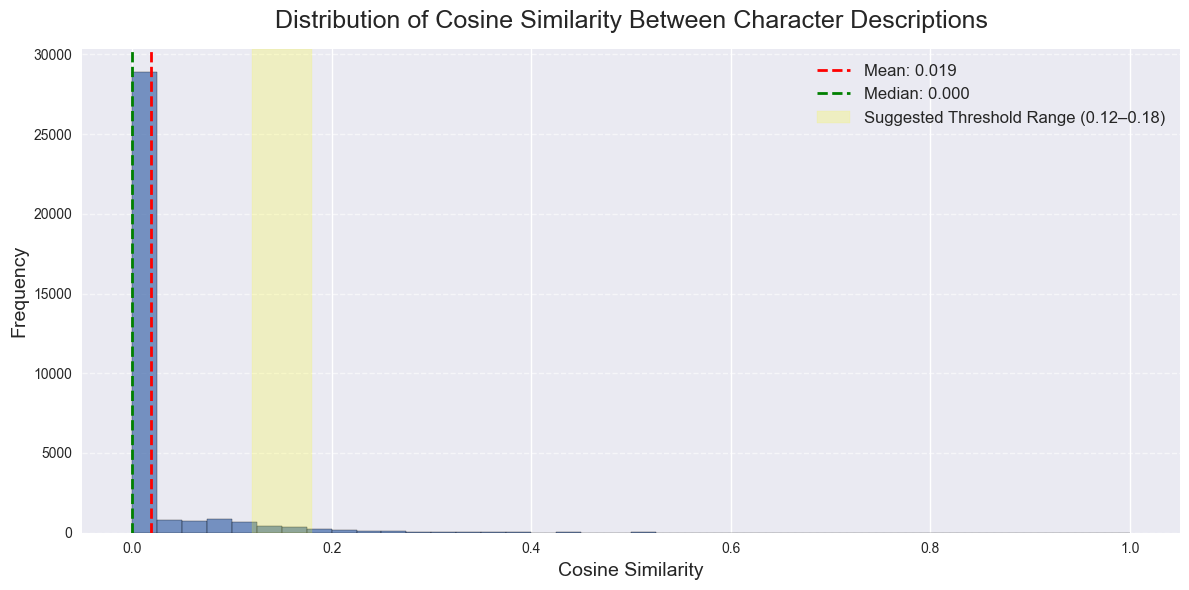

Suggested threshold range for edges: 0.12 – 0.18


In [37]:


similarity_matrix = cosine_similarity(tfidf_matrix)


sim_values = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]


mean_sim = np.mean(sim_values)
median_sim = np.median(sim_values)


plt.figure(figsize=(12, 6))
plt.hist(sim_values, bins=40, edgecolor="black", alpha=0.75, color="#4C72B0")

plt.axvline(mean_sim, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_sim:.3f}")
plt.axvline(median_sim, color="green", linestyle="--", linewidth=2, label=f"Median: {median_sim:.3f}")


plt.axvspan(0.12, 0.18, color="yellow", alpha=0.2, label="Suggested Threshold Range (0.12–0.18)")


plt.title("Distribution of Cosine Similarity Between Character Descriptions", fontsize=18, pad=15)
plt.xlabel("Cosine Similarity", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

print("Suggested threshold range for edges: 0.12 – 0.18")


## Build Similarity Network (Graph Construction)

In this step, we construct a **weighted, undirected network** of Harry Potter characters based on the **semantic similarity** of their descriptions. Each **node** represents a character, and **edges** are drawn between characters whose **TF-IDF cosine similarity** exceeds a chosen threshold (for example, 0.15). The **edge weight** corresponds to the similarity value, reflecting the strength of the narrative or descriptive connection between the characters. By applying this threshold, we ensure that only **meaningful relationships** are captured, avoiding overly dense networks filled with weak or noisy links. This network provides a foundation for **community detection**, visualization, and analysis of how characters naturally cluster based on their textual descriptions rather than predefined groupings like Hogwarts Houses.


This code builds a **weighted, undirected similarity network** of characters based on their TF-IDF cosine similarities. First, a graph `G` is initialized, and each character is added as a **node** with attributes such as name, house, and groups. Then, all pairs of characters are examined, and an **edge is created** between them if their similarity meets or exceeds the **threshold** (0.15 in this case). The **edge weight** is set to the similarity value, reflecting the strength of the connection. Finally, the code prints a summary showing the **total number of nodes and edges**, confirming that the similarity-based network has been successfully constructed. This network is now ready for **community detection** and further analysis of character clusters.


In [38]:

threshold = 0.15  # similarity threshold for edge creation


G = nx.Graph()


for idx, row in df.iterrows():
    G.add_node(
        idx,
        name=row["Name"],
        house=row["House"],
        groups=row["Groups"]
    )


n = similarity_matrix.shape[0]

for i in range(n):
    for j in range(i + 1, n):
        sim = similarity_matrix[i, j]
        if sim >= threshold:
            G.add_edge(i, j, weight=float(sim))

print("Graph construction complete.")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")


Graph construction complete.
Number of nodes: 260
Number of edges: 1324


The code below performs **community detection and visualization** of the Harry Potter character similarity network. First, the **Louvain algorithm** (`community_louvain.best_partition`) is applied to the network, which partitions the nodes into communities by maximizing modularity. Each character is assigned a **community label**, which is added to the dataframe for later analysis. The **degree of each node** is computed to scale node sizes in the visualization, emphasizing more connected characters.

A **fixed layout** is generated using `nx.spring_layout` with a seed, ensuring that node positions remain consistent across plots for easy comparison. Next, **centroids** are calculated for each Louvain community and for each Hogwarts House by averaging the positions of the nodes in each group. These centroids are later used to place labels on the plots for clarity.

Two **side-by-side network visualizations** are then created:
- **Left plot (Communities):** Nodes are colored according to their Louvain community, and node sizes reflect their degree. Gray edges connect nodes based on similarity, while community labels are displayed at the centroids.
- **Right plot (Houses):** Nodes are colored by Hogwarts House, allowing a direct visual comparison between **data-driven communities** and **predefined houses**. House labels are placed at their centroids, and a **legend** is added for clarity. Node sizes and edges are drawn similarly to the community plot.

Overall, this code allows us to **compare Louvain-detected communities with Hogwarts Houses**, highlighting whether houses correspond to natural social clusters or if narrative-driven affiliations produce different groupings in the character network.


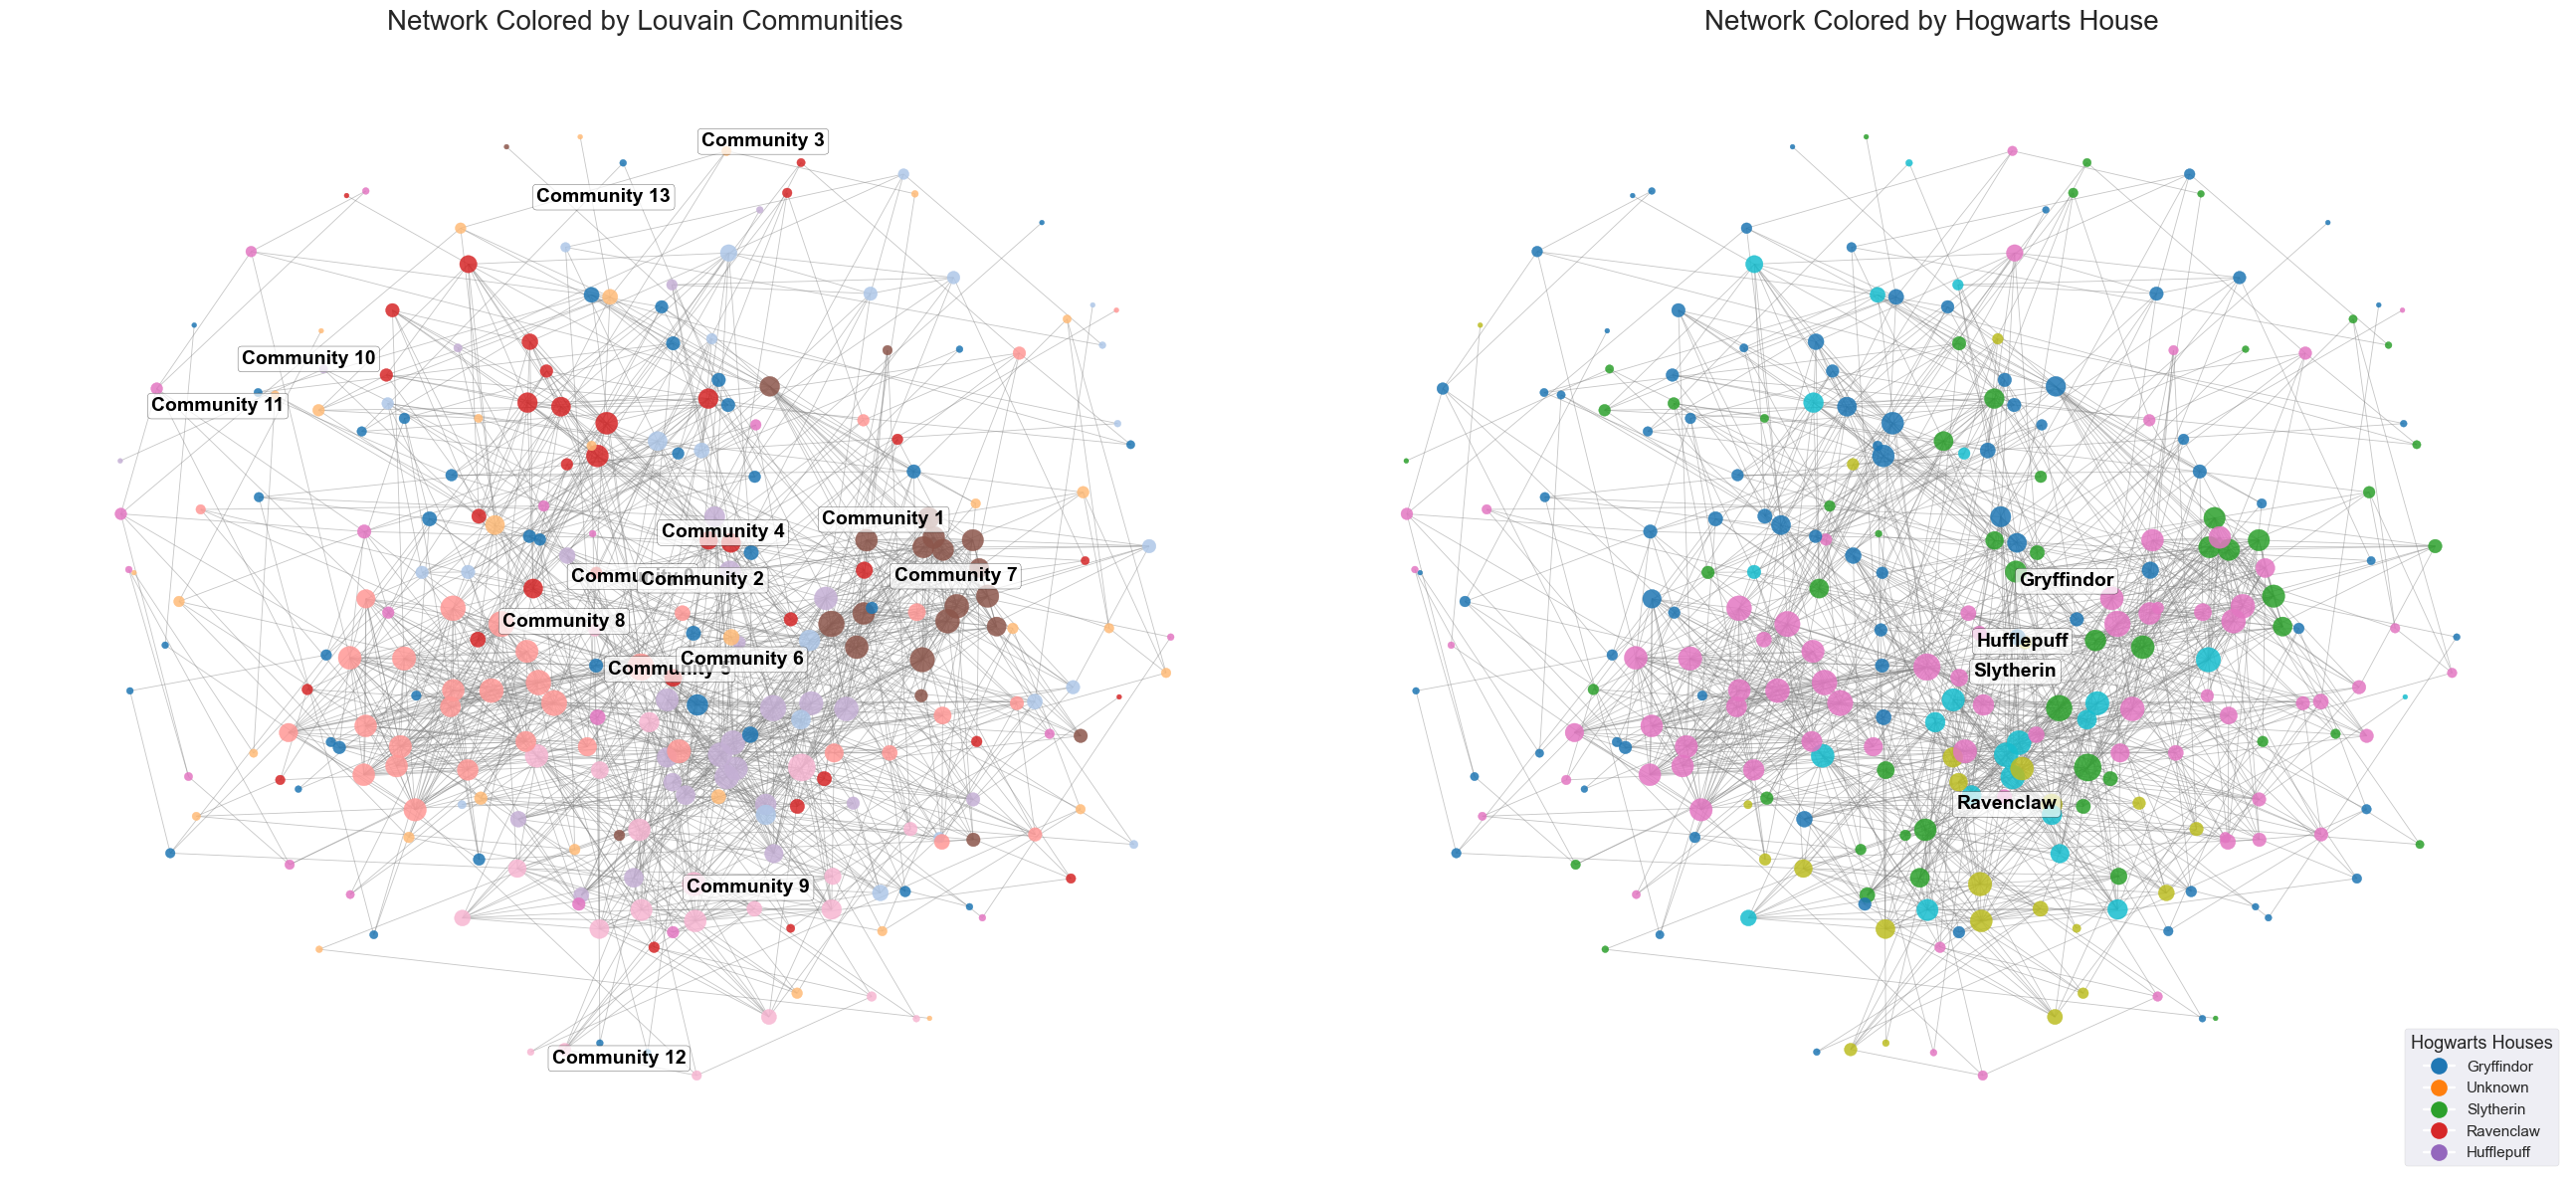

In [39]:

partition = community_louvain.best_partition(G, weight="weight")
df["Community"] = df.index.map(partition)


degrees = dict(G.degree())


pos = nx.spring_layout(G, seed=42, k=0.35)

import numpy as np

community_centroids = {}
for com in set(partition.values()):
    nodes_in_com = [node for node in G.nodes() if partition[node] == com]
    coords = np.array([pos[n] for n in nodes_in_com])
    community_centroids[com] = coords.mean(axis=0)

house_list = df["House"].fillna("Unknown").unique()
house_to_id = {h: i for i, h in enumerate(house_list)}

house_centroids = {}
for house in house_list:
    nodes_in_house = df[df["House"] == house].index.tolist()
    if len(nodes_in_house) > 0:
        coords = np.array([pos[n] for n in nodes_in_house])
        house_centroids[house] = coords.mean(axis=0)


fig, axes = plt.subplots(1, 2, figsize=(26, 12))
ax1, ax2 = axes


community_colors = [partition[node] for node in G.nodes()]

nx.draw_networkx_nodes(
    G, pos, ax=ax1,
    node_size=[degrees[n] * 12 for n in G],
    node_color=community_colors,
    cmap="tab20",
    alpha=0.85
)

nx.draw_networkx_edges(
    G, pos, ax=ax1,
    edge_color="gray",
    width=0.6,
    alpha=0.45
)


for com, (x, y) in community_centroids.items():
    ax1.text(
        x, y, f"Community {com}",
        fontsize=14, fontweight="bold", color="black",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2")
    )

ax1.set_title("Network Colored by Louvain Communities", fontsize=20)
ax1.axis("off")

house_colors = [
    house_to_id[df.loc[n, "House"]] if pd.notna(df.loc[n, "House"]) else -1
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos, ax=ax2,
    node_size=[degrees[n] * 12 for n in G],
    node_color=house_colors,
    cmap="tab10",
    alpha=0.85
)

nx.draw_networkx_edges(
    G, pos, ax=ax2,
    edge_color="gray",
    width=0.6,
    alpha=0.45
)


for house, (x, y) in house_centroids.items():
    ax2.text(
        x, y, house,
        fontsize=14, fontweight="bold", color="black",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.2")
    )

ax2.set_title("Network Colored by Hogwarts House", fontsize=20)
ax2.axis("off")

from matplotlib.lines import Line2D

legend_elements = []
for h, idx in house_to_id.items():
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=plt.cm.tab10(idx),
        markersize=12, label=h
    ))

ax2.legend(
    handles=legend_elements,
    title="Hogwarts Houses",
    fontsize=11,
    title_fontsize=13,
    loc="lower right",
    frameon=True
)

plt.tight_layout()
plt.show()


## Network Statistics

To gain a deeper understanding of the similarity network, we compute several fundamental graph metrics that describe its structure and connectivity:

- **Density:** This measures the proportion of actual edges to all possible edges in the network. A higher density indicates a more interconnected network, while a lower density suggests sparser connections between characters.  
- **Degree distribution:** This shows how many connections (edges) each character (node) has, highlighting which characters are more central or peripheral in the network.  
- **Average, minimum, and maximum degree:** These statistics summarize the overall connectivity. The **average degree** gives a sense of typical connectivity, while the **minimum and maximum degrees** identify the least and most connected characters.  
- **Clustering coefficient:** This metric captures the tendency of characters to form tightly connected triads or clusters. A high clustering coefficient indicates that characters connected to the same individual are also likely to be connected to each other, reflecting tightly-knit social groups.  
- **Largest connected component:** This identifies the largest subset of characters that are all reachable through network connections, representing the main cohesive region of the network.

The code not only calculates these metrics but also **visualizes the degree distribution** using a histogram. Reference lines mark the **mean and median degree**, helping to interpret the typical number of connections per character. By analyzing these statistics, we can identify whether the network has **hubs** (highly connected characters), how clustered it is, and the overall **social structure**. This detailed understanding is essential for interpreting **community detection results** and assessing how well narrative structures like Hogwarts Houses align with the observed network patterns.


Graph Density: 0.0393

Average Degree: 10.18
Minimum Degree: 0
Maximum Degree: 32

Average Clustering Coefficient: 0.1078

Largest Connected Component Size: 255


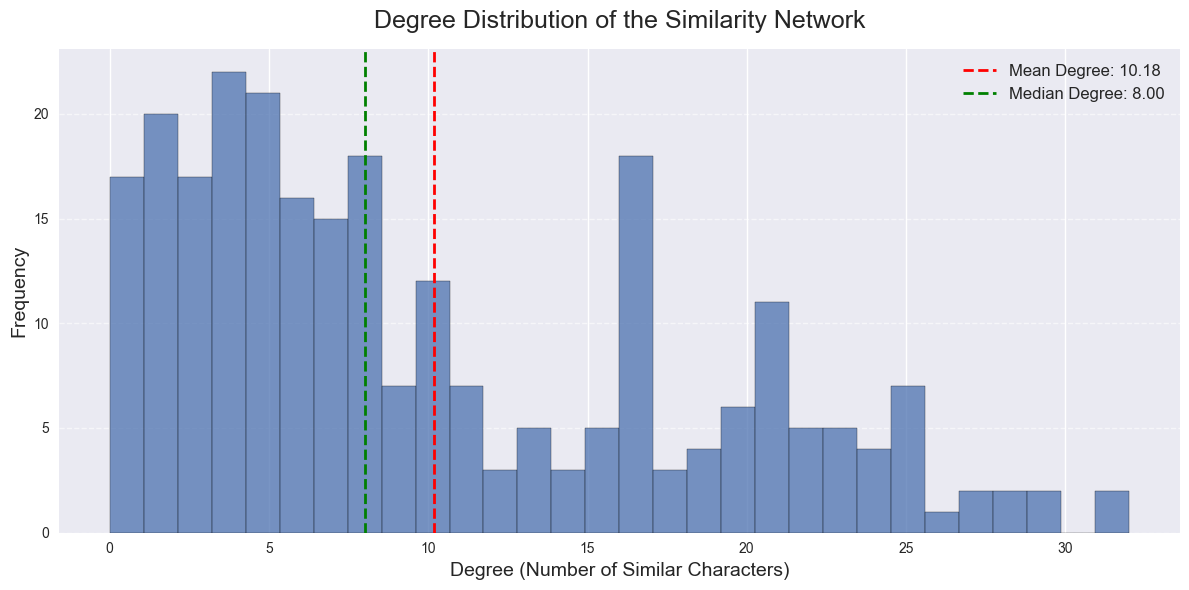

In [40]:

density = nx.density(G)
print(f"Graph Density: {density:.4f}")


degrees = [deg for _, deg in G.degree()]
avg_degree = np.mean(degrees)
min_deg = np.min(degrees)
max_deg = np.max(degrees)

print(f"\nAverage Degree: {avg_degree:.2f}")
print(f"Minimum Degree: {min_deg}")
print(f"Maximum Degree: {max_deg}")

clustering_coeff = nx.average_clustering(G, weight="weight")
print(f"\nAverage Clustering Coefficient: {clustering_coeff:.4f}")

largest_cc = max(nx.connected_components(G), key=len)
print(f"\nLargest Connected Component Size: {len(largest_cc)}")


plt.figure(figsize=(12, 6))

plt.hist(degrees, bins=30, edgecolor="black", alpha=0.75, color="#4C72B0")

mean_deg = np.mean(degrees)
median_deg = np.median(degrees)

plt.axvline(mean_deg, color="red", linestyle="--", linewidth=2, label=f"Mean Degree: {mean_deg:.2f}")
plt.axvline(median_deg, color="green", linestyle="--", linewidth=2, label=f"Median Degree: {median_deg:.2f}")

plt.title("Degree Distribution of the Similarity Network", fontsize=18, pad=15)
plt.xlabel("Degree (Number of Similar Characters)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


This code below prepares **group-level text collections** for analysis by aggregating character descriptions according to their affiliations. First, the `normalize_groups` function standardizes group names by splitting them on commas or semicolons, stripping extra spaces, and converting all names to lowercase, storing the results in the `Groups_norm` column. Next, a dictionary `texts_by_group` collects descriptions for each group: for each character, if they have at least one group and a non-empty description, the **first group** is chosen as the main group, and the character’s description is added to that group’s collection. After all characters are processed, the individual descriptions for each group are **combined into a single document** (`group_docs`), but only for groups with more than 500 characters to ensure sufficient content for meaningful NLP analysis. Finally, the code counts how many characters belong to each group, sorts the groups by size, and prints the **top 20 groups by membership**, giving insight into which affiliations are most represented and suitable for further analysis. This process effectively transforms **character-level descriptions into group-level textual representations**, enabling the study of narrative similarities across affiliations.


In [41]:
from collections import defaultdict
import re

def normalize_groups(x):
    if pd.isna(x):
        return []
    parts = re.split(r"[;,]", str(x))
    return [p.strip().lower() for p in parts if p.strip()]

df["Groups_norm"] = df["Groups"].apply(normalize_groups)

texts_by_group = defaultdict(list)

for _, row in df.iterrows():
    groups = row["Groups_norm"]
    text = str(row["Description"]).strip()

    if not groups or not text:
        continue

    main_group = groups[0]

    texts_by_group[main_group].append(text)

group_docs = {
    g: " ".join(texts)
    for g, texts in texts_by_group.items()
    if len(" ".join(texts).strip()) > 500  
}


group_counts = {g: len(v) for g, v in texts_by_group.items()}
sorted_groups = sorted(group_counts.items(), key=lambda x: x[1], reverse=True)

print(f"Group documents built: {len(group_docs)}\n")
print("Top groups by number of characters:\n")

for g, count in sorted_groups[:20]:
    print(f"{g:30s} → {count} characters")


Group documents built: 4

Top groups by number of characters:

['dumbledores army             → 20 characters
['order of the phoenix']       → 15 characters
['death eaters']               → 15 characters
['death eaters                 → 12 characters
['hufflepuff student']         → 8 characters
['order of the phoenix         → 7 characters
['ministry of magic            → 6 characters
['gryffindor quidditch team']  → 6 characters
['ravenclaw student']          → 6 characters
['slytherin quidditch team']   → 6 characters
['slytherin student            → 6 characters
['hogwarts ghost']             → 5 characters
['black family']               → 5 characters
['gryffindor student']         → 4 characters
['slytherin student']          → 4 characters
['hogwarts founder']           → 4 characters
['dursley family']             → 4 characters
['gryffindor student           → 3 characters
['weasley family               → 3 characters
['hogwarts headmaster']        → 3 characters


This code helps us determine the **size of each Louvain community**, providing a clear numeric summary of how characters are distributed across the detected communities in the network. Knowing the community sizes is important for **further analysis**, such as comparing these data-driven clusters with Hogwarts Houses, identifying large or small social groups, and understanding the structure and cohesion of character networks.


In [42]:
partition = community_louvain.best_partition(G, weight="weight")

df["Community"] = df.index.map(partition)

community_sizes = df["Community"].value_counts().sort_index()
num_coms = len(community_sizes)

print(f"Number of Communities: {num_coms}\n")
print("Community    Size")
for com, size in community_sizes.items():
    print(f"{str(com).ljust(12)} {size}")


Number of Communities: 13

Community    Size
0            1
1            46
2            1
3            34
4            41
5            29
6            24
7            1
8            31
9            31
10           19
11           1
12           1


This code snippet below builds **textual documents for each Hogwarts House** by aggregating the descriptions of all characters belonging to that house. The process works as follows: for each unique house in the dataset (ignoring missing values), it collects all character descriptions in that house into a list, then **combines them into a single string**. A minimum length check (`>30 characters`) ensures that empty or nearly empty houses are skipped. The resulting `house_docs` dictionary maps each house to its combined textual content. Finally, the code prints the number of house documents created and reports the **word count** for each house. 

**Purpose and Importance:** Creating house-level documents allows us to perform **NLP analyses at the house level**, such as computing **semantic similarity between houses** or comparing house texts to community-level documents. This helps in understanding whether the textual descriptions of characters align with the predefined Hogwarts House structure or if narrative-driven communities diverge from house divisions.


In [43]:
house_docs = {}

for h in sorted(df["House"].dropna().unique()):
    texts = df[df["House"] == h]["Description"].tolist()
    combined = " ".join(texts).strip()
    if len(combined) > 30:  # avoid empty houses
        house_docs[h] = combined

print("House documents built:", len(house_docs))
for h, text in house_docs.items():
    print(f"- {h}: {len(text.split())} words")


House documents built: 4
- Gryffindor: 490 words
- Hufflepuff: 158 words
- Ravenclaw: 189 words
- Slytherin: 561 words


This code computes **TF-IDF scores for each Hogwarts House** to identify the most distinctive words in the combined descriptions of characters within each house. First, it collects the house labels and corresponding combined text documents (`house_docs`). The `TfidfVectorizer` converts each house’s text into a **numerical TF-IDF vector**, giving higher weights to words that are important or unique within that house and lower weights to common words across all houses. The function `print_top_terms` then extracts the **top N terms with the highest TF-IDF scores** for each house and prints them, showing which words best represent each house’s textual profile.

This step helps us understand the **semantic identity of each house** based on character descriptions. By analyzing the top TF-IDF terms, we can see which words distinguish Gryffindor, Slytherin, Hufflepuff, and Ravenclaw. These insights are useful for **comparing house texts to community-level clusters**, checking if house divisions reflect actual narrative patterns, and interpreting the thematic focus of each house in the social network.


In [44]:


from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

h_labels = list(house_docs.keys())
h_docs  = [house_docs[h] for h in h_labels]

vec_h = TfidfVectorizer(stop_words='english', max_features=8000)
Xh = vec_h.fit_transform(h_docs)
terms_h = vec_h.get_feature_names_out()

def print_top_terms(X, terms, labels, top_n=10):
    for i, lab in enumerate(labels):
        row = X[i].toarray()[0]
        idx = np.argsort(row)[::-1][:top_n]
        print(f"\nTop {top_n} TF-IDF terms — {lab}:")
        for j in idx:
            print(f"  {terms[j]}: {row[j]:.4f}")

print("\nTF-IDF (Houses) matrix:", Xh.shape)
print_top_terms(Xh, terms_h, h_labels, top_n=10)



TF-IDF (Houses) matrix: (4, 435)

Top 10 TF-IDF terms — Gryffindor:
  gryffindor: 0.4890
  harry: 0.2669
  student: 0.2159
  known: 0.2159
  weasley: 0.1780
  quidditch: 0.1767
  member: 0.1570
  friend: 0.1505
  harrys: 0.1505
  family: 0.1441

Top 10 TF-IDF terms — Hufflepuff:
  hufflepuff: 0.6596
  student: 0.3098
  briefly: 0.2526
  da: 0.2105
  known: 0.2065
  mentioned: 0.2065
  member: 0.1721
  minor: 0.1377
  fairness: 0.1319
  loyalty: 0.1040

Top 10 TF-IDF terms — Ravenclaw:
  ravenclaw: 0.5794
  student: 0.3024
  da: 0.2876
  sorting: 0.2575
  member: 0.2352
  present: 0.1288
  studious: 0.1288
  yule: 0.1015
  teacher: 0.1015
  dates: 0.1015

Top 10 TF-IDF terms — Slytherin:
  eater: 0.4911
  slytherin: 0.3975
  death: 0.3872
  pure: 0.2105
  blood: 0.2105
  voldemort: 0.1940
  dark: 0.1871
  known: 0.1464
  involved: 0.1403
  wizard: 0.1291


This code below generates **WordCloud visualizations for each Hogwarts House** based on the combined character descriptions. For every house in `h_labels`, it creates a WordCloud object that visualizes the most frequent and distinctive words from `house_docs[h]`. The generated word cloud is displayed using `matplotlib`, with larger words representing higher frequency or importance. The plot is formatted with a white background, no axes, and a title indicating the house name.

WordClouds provide a **quick, visual summary of the key terms** that characterize each house. Unlike TF-IDF tables, WordClouds make it easy to **see patterns and thematic emphasis at a glance**, helping to interpret semantic differences between houses. This visual representation complements numeric TF-IDF analysis and can be compared to community-level clusters to assess whether house-based textual patterns align with detected social communities.



Generating WordCloud for House: Gryffindor


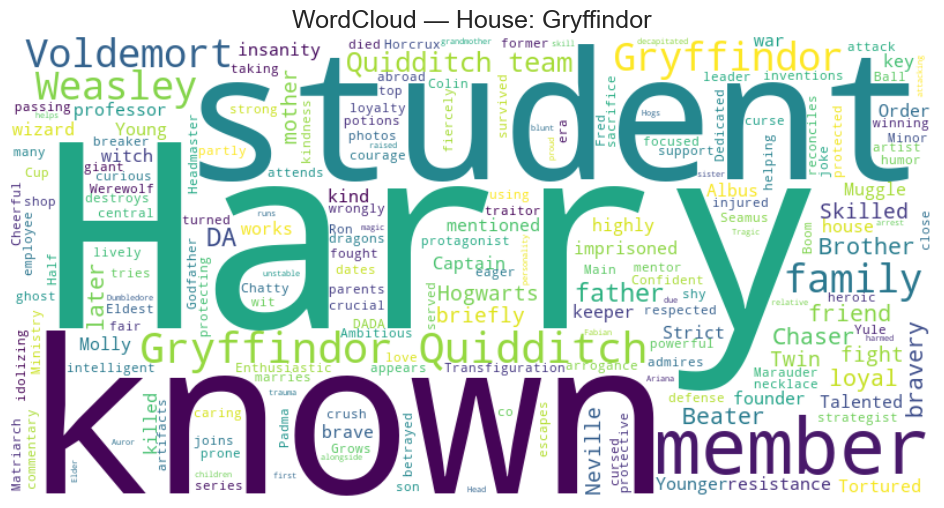


Generating WordCloud for House: Hufflepuff


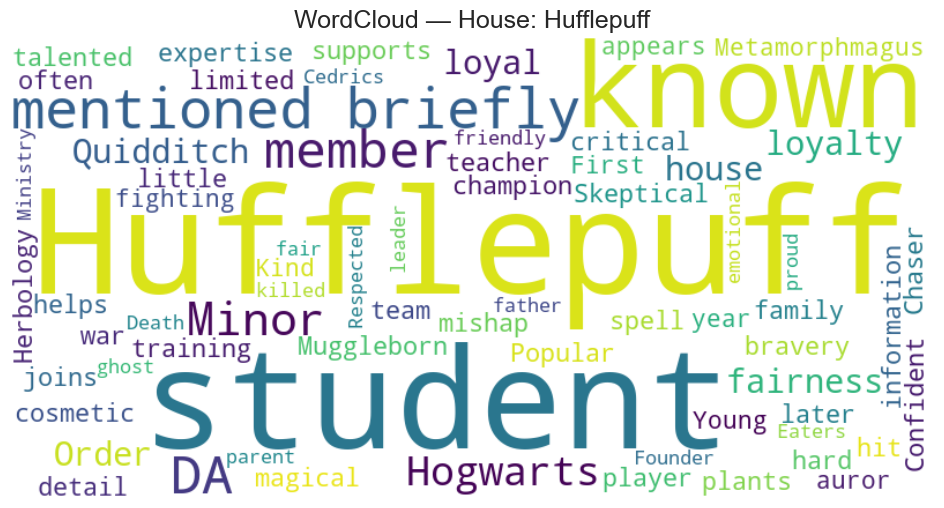


Generating WordCloud for House: Ravenclaw


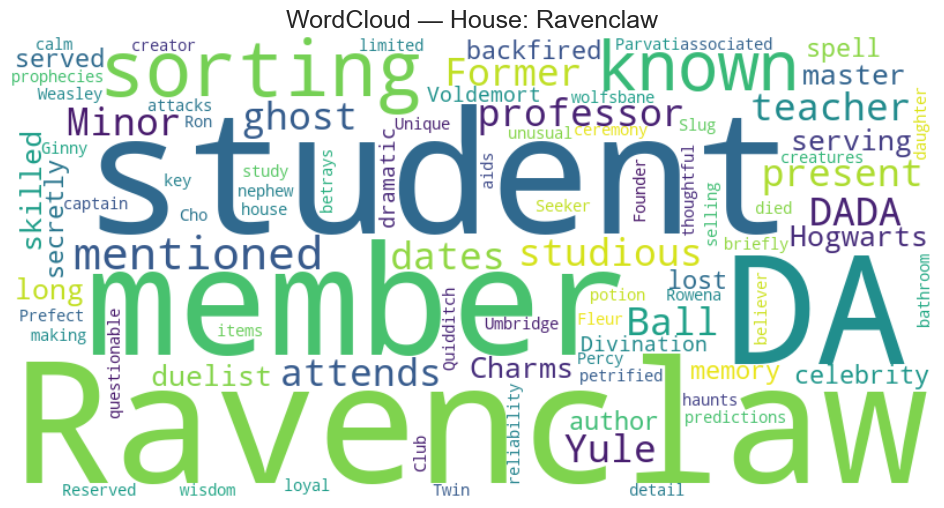


Generating WordCloud for House: Slytherin


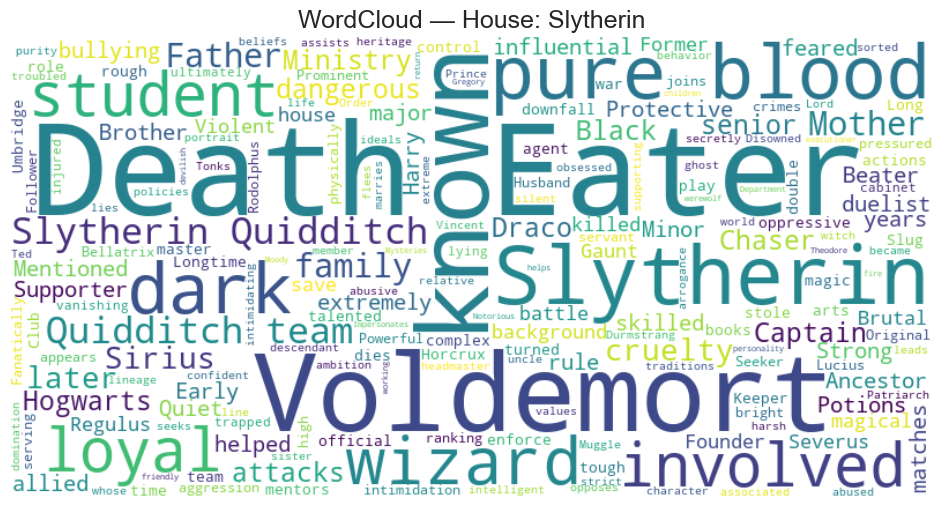

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for h in h_labels:
    print(f"\nGenerating WordCloud for House: {h}")

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(house_docs[h])

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — House: {h}", fontsize=18)
    plt.show()


This code below builds **textual documents for each detected Louvain community** by aggregating the descriptions of all characters assigned to that community. For each unique community in the dataframe, it collects all character descriptions in that community into a list, then **combines them into a single string**. A minimum length check (`>30 characters`) ensures that very small or empty communities are skipped. The resulting `community_docs` dictionary maps each community to its combined textual content. Finally, the code prints the number of community documents created and reports the **word count** for each community.

**Purpose and Importance:** Creating community-level documents allows us to perform **NLP analyses at the community level**, similar to what was done for houses. These documents enable comparisons between **data-driven community clusters** and predefined Hogwarts Houses, helping us determine whether natural clusters in the network reflect house divisions, narrative roles, or other social structures.


In [46]:
community_docs = {}

for com in sorted(df["Community"].unique()):
    texts = df[df["Community"] == com]["Description"].tolist()
    combined = " ".join(texts).strip()
    if len(combined) > 30:
        community_docs[com] = combined

print("Community documents built:", len(community_docs))
for c, text in community_docs.items():
    print(f"Community {c}: {len(text.split())} words")


Community documents built: 13
Community 0: 6 words
Community 1: 404 words
Community 2: 6 words
Community 3: 266 words
Community 4: 358 words
Community 5: 193 words
Community 6: 166 words
Community 7: 9 words
Community 8: 261 words
Community 9: 241 words
Community 10: 143 words
Community 11: 6 words
Community 12: 8 words


This code snippet below computes **TF-IDF scores for each Louvain community** to identify the most distinctive words in the combined descriptions of characters within each community. First, it collects the community labels and corresponding combined text documents (`community_docs`). The `TfidfVectorizer` converts each community’s text into a **numerical TF-IDF vector**, highlighting words that are important or unique within that community. The `print_top_terms` function then extracts and prints the **top 10 TF-IDF terms** for each community, showing which words best represent the textual profile of each cluster.

This step helps us understand the **semantic identity of each detected community**. By comparing the top TF-IDF terms of communities with those of Hogwarts Houses, we can assess whether the **natural clusters detected in the network align with house divisions**, or if they are driven by other factors such as narrative roles, families, or affiliations. This is crucial for interpreting how closely textual content reflects social structure.


In [47]:
c_labels = list(community_docs.keys())
c_docs  = [community_docs[c] for c in c_labels]

vec_c = TfidfVectorizer(stop_words='english', max_features=8000)
Xc = vec_c.fit_transform(c_docs)
terms_c = vec_c.get_feature_names_out()

print("\nTF-IDF (Communities) matrix:", Xc.shape)
print_top_terms(Xc, terms_c, c_labels, top_n=10)



TF-IDF (Communities) matrix: (13, 645)

Top 10 TF-IDF terms — 0:
  prophecy: 0.5429
  guards: 0.5429
  hall: 0.5429
  member: 0.3404
  following: 0.0000
  follower: 0.0000
  focused: 0.0000
  flying: 0.0000
  fleur: 0.0000
  flees: 0.0000

Top 10 TF-IDF terms — 1:
  order: 0.4289
  killed: 0.3026
  member: 0.2689
  known: 0.2476
  war: 0.2354
  brave: 0.1949
  portrait: 0.1560
  original: 0.1560
  friend: 0.1345
  auror: 0.1193

Top 10 TF-IDF terms — 2:
  healing: 0.4834
  phoenix: 0.4834
  dumbledores: 0.4834
  tears: 0.4834
  loyal: 0.2559
  fleur: 0.0000
  foolish: 0.0000
  following: 0.0000
  follower: 0.0000
  focused: 0.0000

Top 10 TF-IDF terms — 3:
  eater: 0.6305
  death: 0.5437
  blood: 0.2579
  pure: 0.2579
  sirius: 0.1146
  involved: 0.1096
  senior: 0.0860
  dangerous: 0.0860
  voldemort: 0.0824
  loyal: 0.0759

Top 10 TF-IDF terms — 4:
  magical: 0.4192
  wizard: 0.2565
  strict: 0.2531
  known: 0.2472
  hogwarts: 0.2409
  students: 0.2096
  professor: 0.1808
  dark: 0.

This code below generates **WordCloud visualizations for each detected Louvain community** using the combined descriptions stored in `community_docs`. For every community in `c_labels`, it creates a WordCloud where larger words represent higher frequency or importance in that community’s text. The WordCloud is displayed using `matplotlib` with a white background, no axes, and a title indicating the community number.

WordClouds provide a **visual summary of key terms** that characterize each community, making it easy to quickly identify themes, traits, or affiliations that define the cluster. This visualization complements the TF-IDF analysis, helping to **interpret the semantic content of communities** and compare them with Hogwarts Houses or other narrative structures in the network.



Generating WordCloud for Community: 0


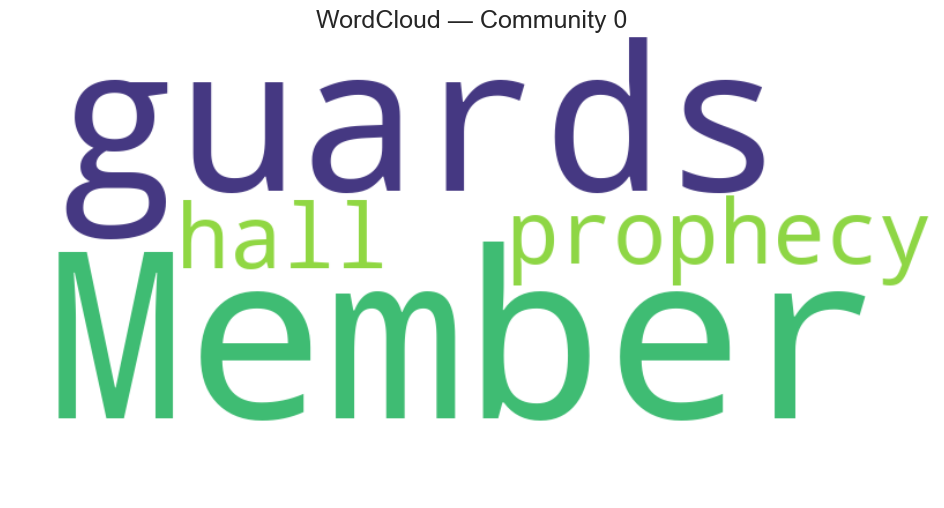


Generating WordCloud for Community: 1


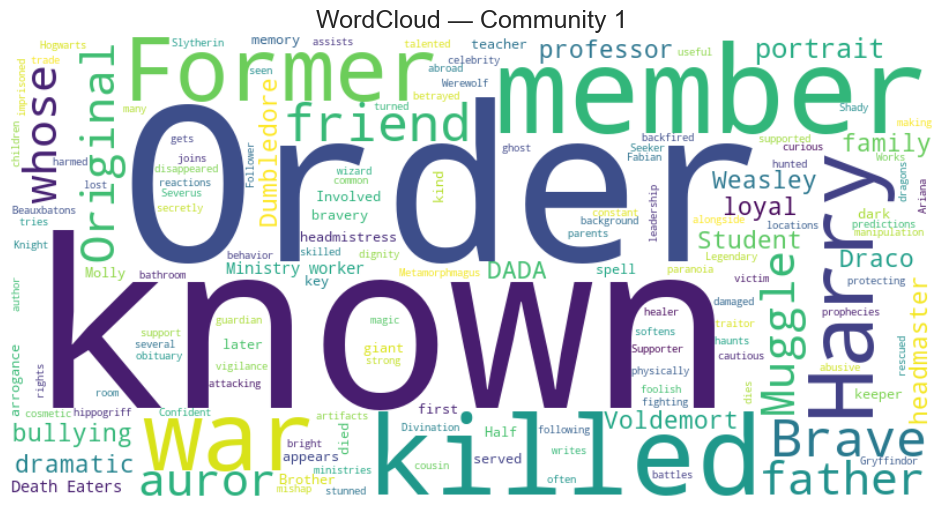


Generating WordCloud for Community: 2


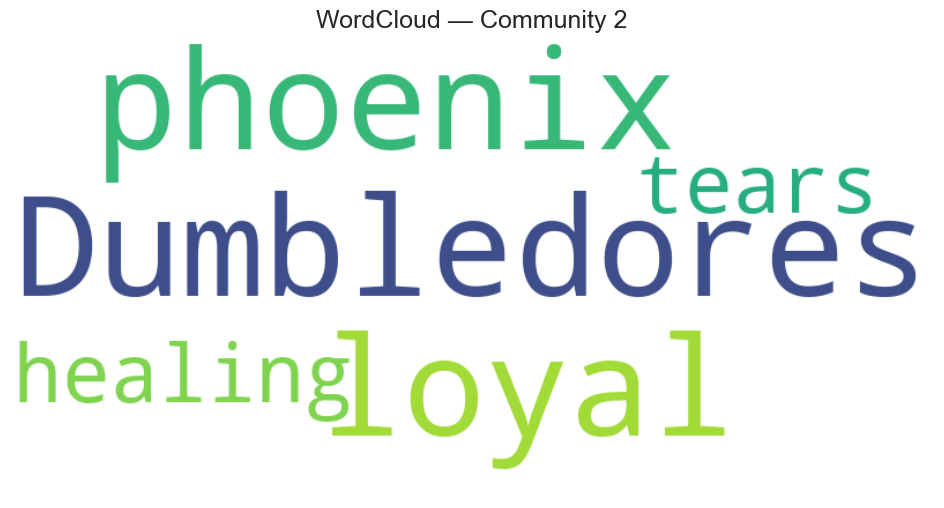


Generating WordCloud for Community: 3


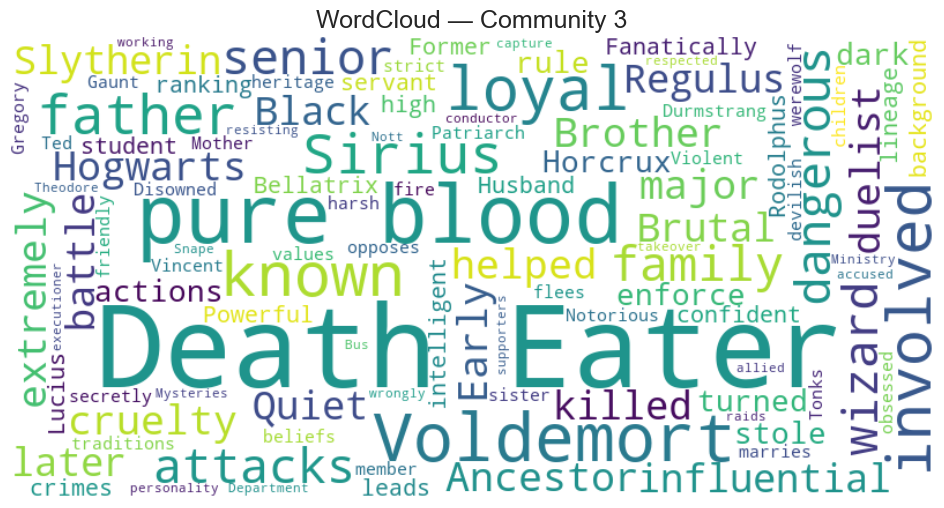


Generating WordCloud for Community: 4


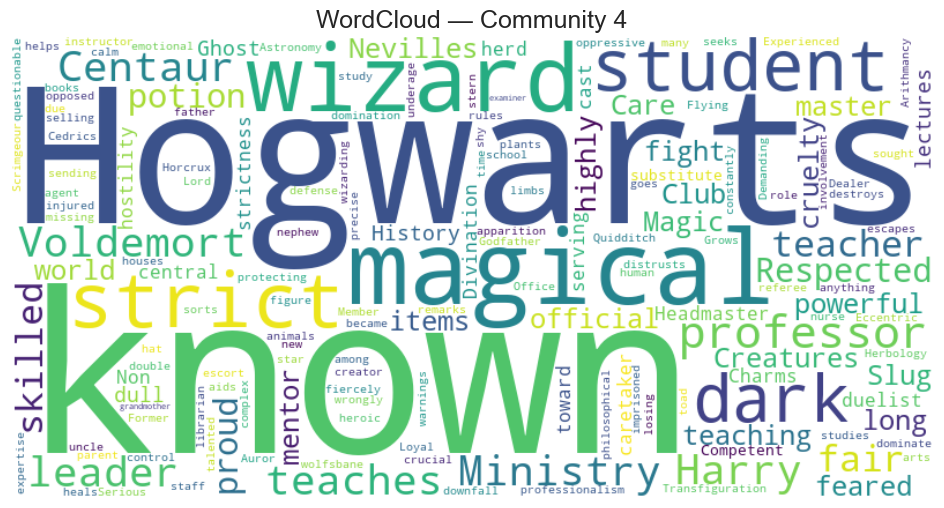


Generating WordCloud for Community: 5


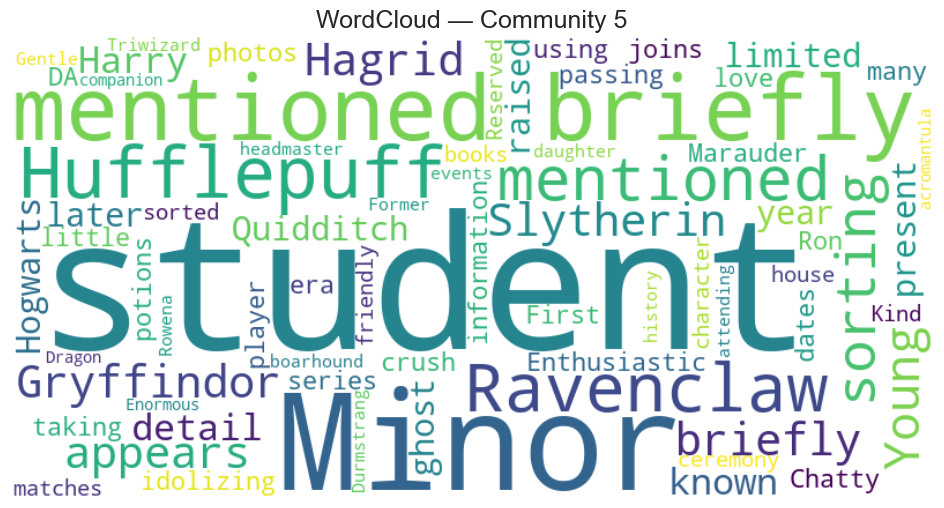


Generating WordCloud for Community: 6


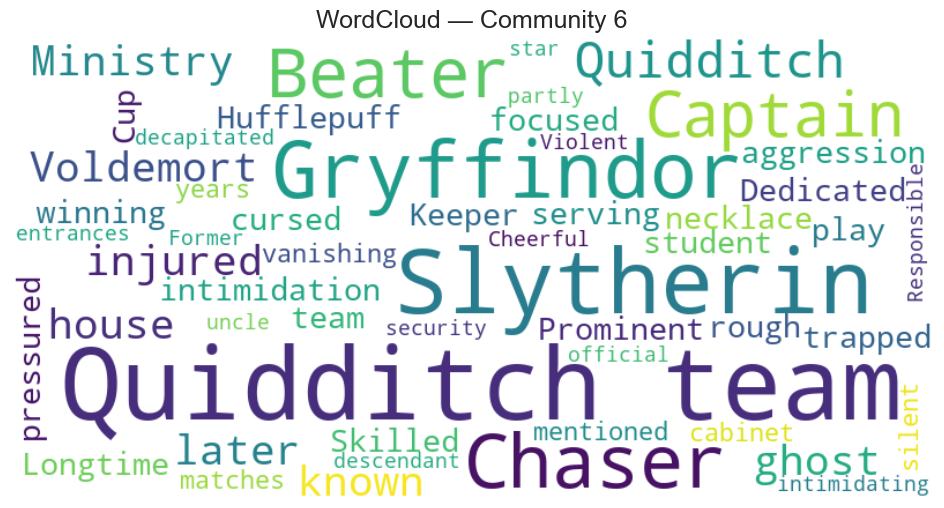


Generating WordCloud for Community: 7


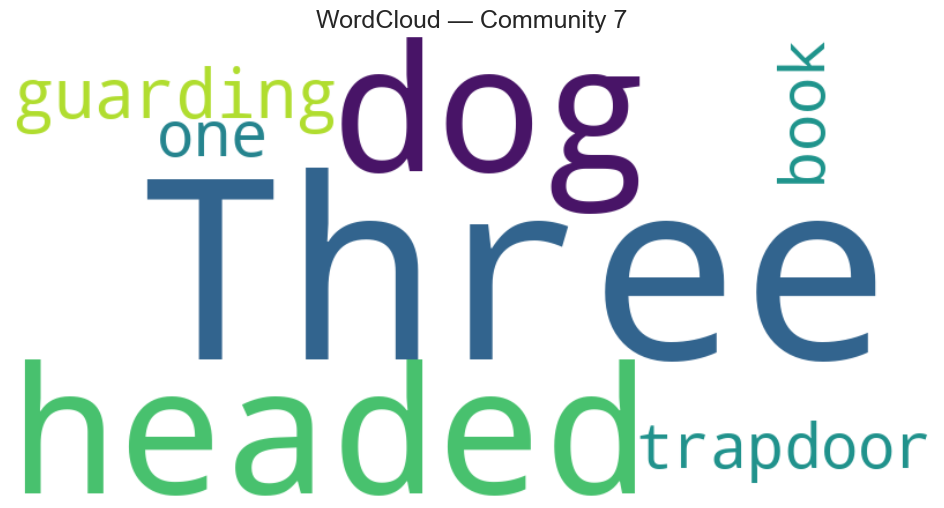


Generating WordCloud for Community: 8


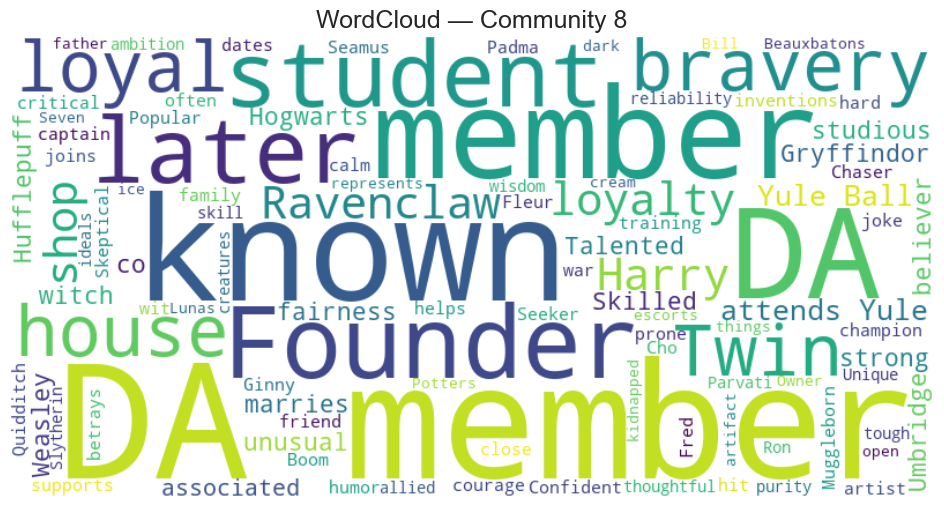


Generating WordCloud for Community: 9


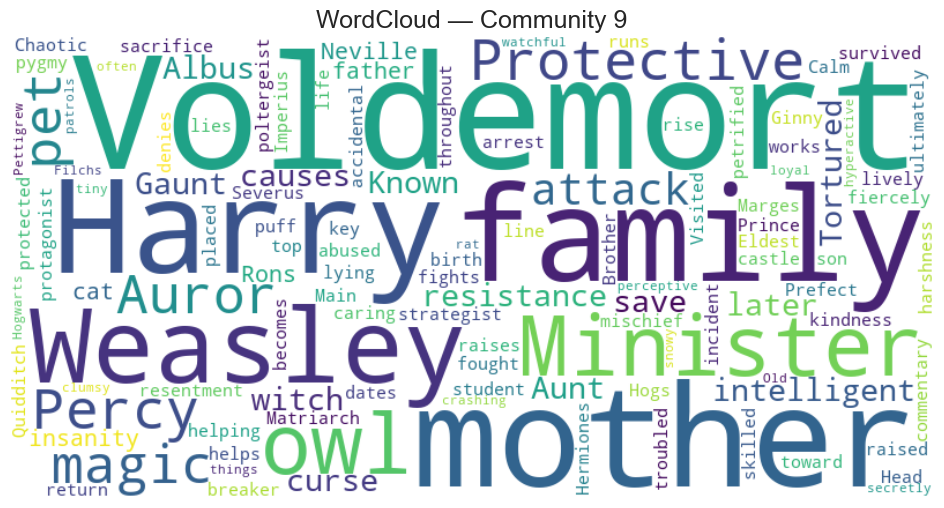


Generating WordCloud for Community: 10


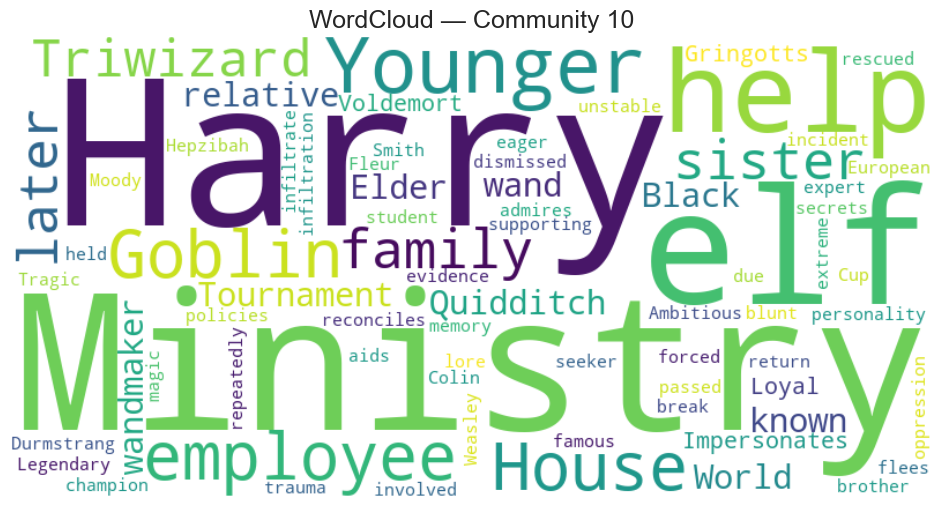


Generating WordCloud for Community: 11


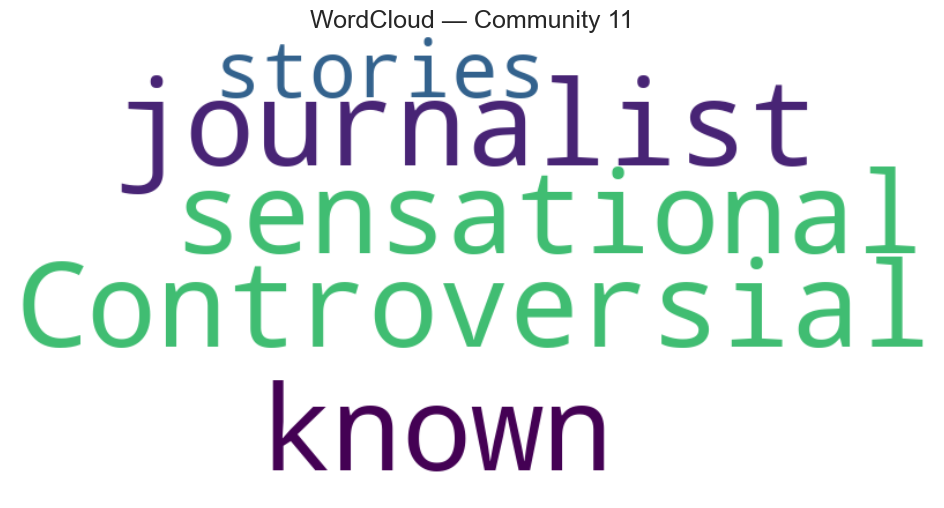


Generating WordCloud for Community: 12


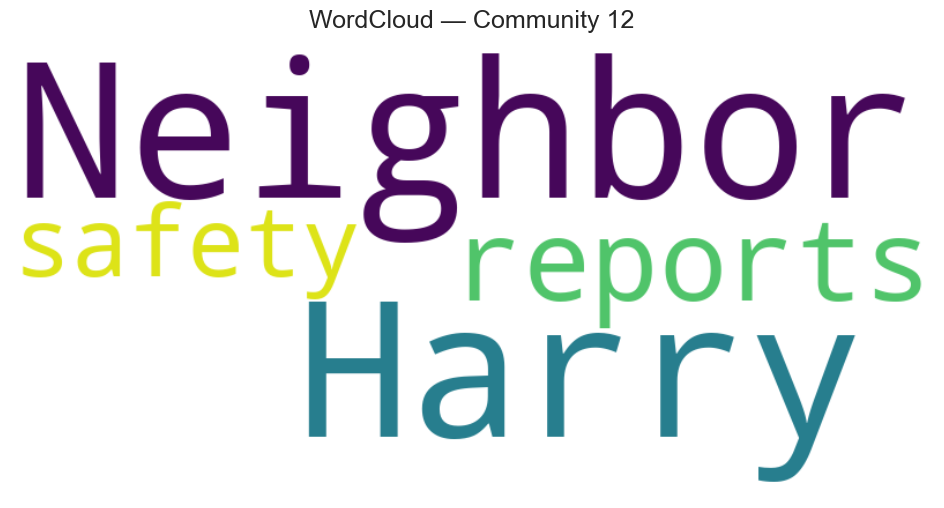

In [48]:
for com in c_labels:
    print(f"\nGenerating WordCloud for Community: {com}")

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(community_docs[com])

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud — Community {com}", fontsize=18)
    plt.show()


This code constructs a **D-matrix (House vs Community)** to quantify the overlap between **Hogwarts Houses** and **detected Louvain communities**.  

**Explanation:**  
1. First, it collects the list of unique houses (`houses`) and communities (`communities`).  
2. It initializes a zero matrix `D` with rows = houses and columns = communities.  
3. Dictionaries `house_idx` and `comm_idx` map house and community labels to their corresponding row/column indices in the matrix.  
4. The code iterates through each character in the dataframe and increments the corresponding cell in the matrix based on that character’s house and community. For example, if a character belongs to Gryffindor and Community 2, the cell `D["Gryffindor", "Community_2"]` is incremented by 1.  
5. Finally, the matrix is converted to a `pandas DataFrame` for readability and printed.

**Inference:**  
- The D-matrix shows how characters from each house are distributed across the detected communities.  
- It allows us to see whether **Houses align with communities** (e.g., a house concentrated in a single community) or whether **communities mix multiple houses**, indicating that social clusters are not strictly house-based.  
- We can identify **strong overlaps, mixed communities, or outliers** where certain characters are grouped differently than their house.  

**Purpose and Necessity:**  
This step is crucial for **comparing the data-driven community structure with predefined houses**. It provides a **quantitative measure of alignment**, helping answer the central research question: *Do Hogwarts Houses reflect real social communities, or are narrative-driven clusters more significant?* The D-matrix serves as the foundation for further visualizations or statistical analyses.


In [49]:
import pandas as pd
import numpy as np

houses = sorted(df["House"].dropna().unique())
communities = sorted(df["Community"].unique())

# Initialize matrix
D = np.zeros((len(houses), len(communities)), dtype=int)

house_idx = {h:i for i, h in enumerate(houses)}
comm_idx = {c:j for j, c in enumerate(communities)}

# Fill matrix
for _, row in df.iterrows():
    h = row["House"]
    c = row["Community"]
    if h in house_idx:
        D[house_idx[h], comm_idx[c]] += 1

# Convert to DataFrame
D_df = pd.DataFrame(D,
                    index=houses,
                    columns=[f"Community_{c}" for c in communities])

print(D_df)


            Community_0  Community_1  Community_2  Community_3  Community_4  \
Gryffindor            0           11            0            0            5   
Hufflepuff            0            3            0            0            3   
Ravenclaw             0            4            0            0            3   
Slytherin             0            6            0           33            7   

            Community_5  Community_6  Community_7  Community_8  Community_9  \
Gryffindor            6            9            0            8           10   
Hufflepuff            9            1            0            7            0   
Ravenclaw             6            0            0            9            1   
Slytherin             3           12            0            3            5   

            Community_10  Community_11  Community_12  
Gryffindor             4             0             0  
Hufflepuff             0             0             0  
Ravenclaw              0             0     

This code performs **sentiment analysis** on the descriptions of Harry Potter characters to assess the overall emotional tone associated with each character. It uses either **VADER** or **TextBlob** as the sentiment library, with VADER initialized in this snippet. The `sentiment_scores_fast` function computes a **compound sentiment score** for a given text, returning 0 for empty or missing descriptions.  

The code then iterates through each character in the dataset, extracting the description, house, and community, and applies the sentiment function. Results are stored in a list of dictionaries containing the character’s name, computed sentiment, house, and community. Any exceptions during computation are caught, and a default sentiment of 0 is assigned. Finally, this list is converted into a **pandas DataFrame (`hp_sentiment_df`)**, which provides a structured table of sentiment scores for all characters.

**Purpose and Importance:**  
- This step allows us to **quantitatively capture the emotional tone** of each character’s description.  
- Including **house and community information** enables us to analyze sentiment patterns across social clusters and compare whether certain communities or houses have more positive or negative portrayals.  
- The resulting dataframe is essential for **downstream analyses**, such as plotting sentiment distributions, correlating sentiment with network positions, or investigating whether narrative clusters differ in emotional tone, adding an additional layer of insight to the social network analysis.


In [50]:
from tqdm import tqdm
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# -------------------------
# Choose library
# -------------------------
SENTIMENT_LIB = "vader"   # or "textblob"

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# -------------------------
# Sentiment function
# -------------------------
def sentiment_scores_fast(text: str) -> float:
    if not text or not text.strip():
        return 0.0

    if SENTIMENT_LIB == "vader":
        return sia.polarity_scores(text)["compound"]
    else:
        return float(TextBlob(text).sentiment.polarity)

# -------------------------
# Build sentiment dataframe
# -------------------------

rows = []
for idx, row in tqdm(df.iterrows(), 
                     total=df.shape[0], 
                     desc="Analyzing sentiments", 
                     unit="character"):

    desc = row["Description"]
    house = row.get("House", None)
    community = row.get("Community", None)

    try:
        rows.append({
            "Character": row["Name"],
            "Sentiment": sentiment_scores_fast(desc),
            "House": house,
            "Community": community
        })
    except Exception:
        rows.append({
            "Character": row["Name"],
            "Sentiment": 0.0,
            "House": house,
            "Community": community
        })

hp_sentiment_df = pd.DataFrame(rows)

print("Sentiment dataframe created with", len(hp_sentiment_df), "characters")
hp_sentiment_df.head()


Analyzing sentiments: 100%|█████████| 260/260 [00:00<00:00, 19741.83character/s]

Sentiment dataframe created with 260 characters


,Character,Sentiment,House,Community
0,Harry Potter,-0.2732,Gryffindor,9
1,Ron Weasley,0.8074,Gryffindor,1
2,Hermione Granger,0.3774,Gryffindor,9
3,Professor Binns,-0.6124,NaN,4
4,Charity Burbage,-0.7964,NaN,1


This code snippet below visualizes the **distribution of sentiment scores** for Harry Potter character descriptions using a histogram. It takes the `hp_sentiment_df` dataframe and extracts the `Sentiment` column, dropping any missing values. A histogram with 40 bins is plotted, showing how many characters fall into different sentiment ranges. The **mean** and **median** sentiment values are overlaid as red and green dashed lines, respectively, to provide reference points for the central tendency of the distribution.  

- The histogram allows us to **quickly understand the overall emotional tone** of character descriptions whether they are mostly positive, negative, or neutral.  
- Overlaying mean and median helps identify **skewness** or asymmetry in the sentiment distribution.  
- This visualization is useful for comparing **sentiment across houses or communities** later, revealing whether certain groups or clusters tend to have more positive or negative portrayals. It complements the network and community analyses by adding an **affective layer** to the social structure of the Harry Potter universe.


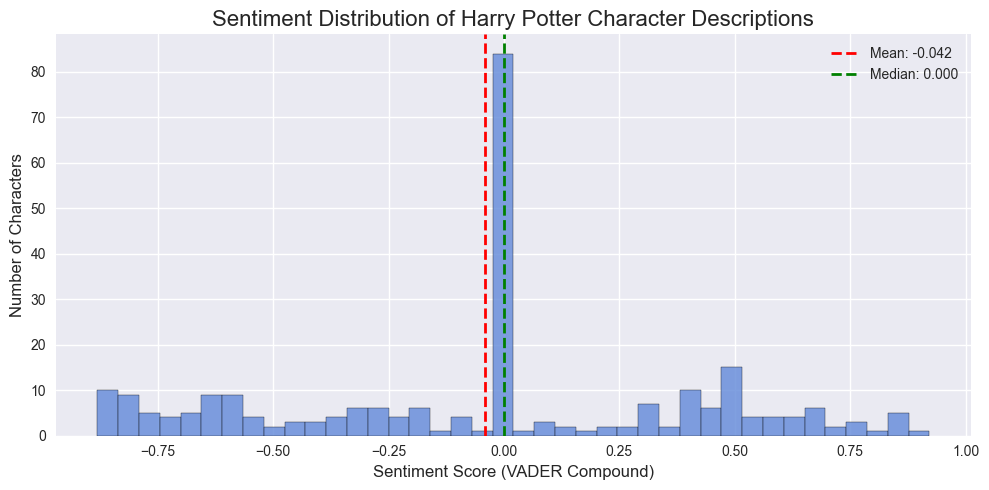

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Use your sentiment dataframe
df_sent = hp_sentiment_df

sentiments = df_sent["Sentiment"].dropna()

plt.figure(figsize=(10, 5))

# Histogram
plt.hist(sentiments, bins=40, color="#6A8FDB", edgecolor="black", alpha=0.85)

# Mean & Median lines
mean_val = sentiments.mean()
median_val = sentiments.median()

plt.axvline(mean_val, color="red", linestyle="dashed", linewidth=2,
            label=f"Mean: {mean_val:.3f}")
plt.axvline(median_val, color="green", linestyle="dashed", linewidth=2,
            label=f"Median: {median_val:.3f}")

# Titles and labels
plt.title("Sentiment Distribution of Harry Potter Character Descriptions", fontsize=16)
plt.xlabel("Sentiment Score (VADER Compound)", fontsize=12)
plt.ylabel("Number of Characters", fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()


This code visualizes the **sentiment distribution of characters within each Louvain-detected community** using a combination of a **boxplot** and a **stripplot**. The boxplot summarizes the spread of sentiment scores for each community, showing the median, quartiles, and interquartile range, while outliers are hidden for cleaner visuals. The stripplot overlays individual character points in black, allowing us to see the density and variation of sentiment scores within each community.  

**Purpose and Importance:**  
- This plot helps identify whether some communities are **more positive or negative** than others, revealing **affective patterns within social clusters**.  
- It allows comparison between communities and can indicate whether **community structure aligns with sentiment trends**, which adds a new dimension to understanding social and narrative groupings.  
- By combining boxplots and individual points, it captures both **overall trends and individual variations**, making it a valuable tool for interpreting emotional tone alongside network-based communities.


/var/folders/jc/p45t40ys24v4ch9xx2srqw1r0000gn/T/ipykernel_53309/1780545439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


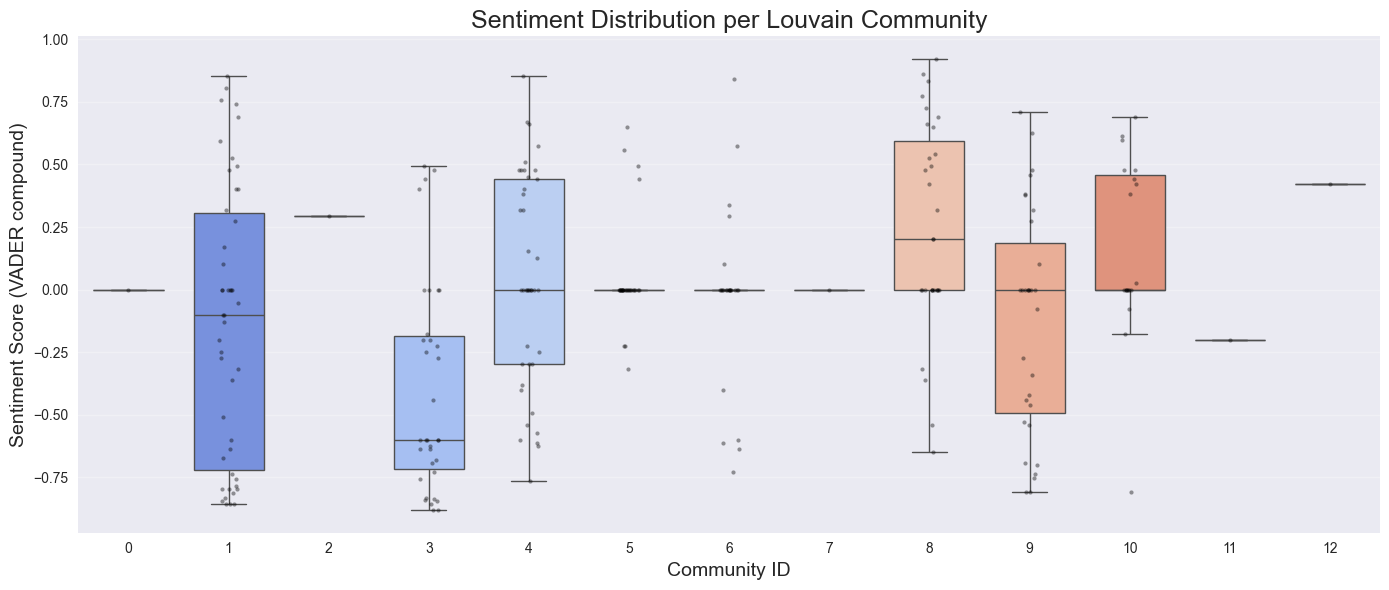

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=hp_sentiment_df,
    x="Community",
    y="Sentiment",
    palette="coolwarm",
    width=0.7,
    showfliers=False   # removes extreme dots for cleaner visuals
)

sns.stripplot(
    data=hp_sentiment_df,
    x="Community",
    y="Sentiment",
    color="black",
    size=3,
    alpha=0.4
)

plt.title("Sentiment Distribution per Louvain Community", fontsize=18)
plt.xlabel("Community ID", fontsize=14)
plt.ylabel("Sentiment Score (VADER compound)", fontsize=14)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

In this notebook, we conducted a comprehensive network-based analysis of the social structure in the Harry Potter book series. We began by building a dataset from two complementary sources: the Muggles’ Guide, which provides character appearances and affiliations, and detailed book summaries that add narrative context for characters with sparse metadata. Using these materials, we constructed a character co-occurrence network where nodes represent characters and edges represent shared chapter appearances. After filtering minor and duplicate characters, we analyzed the structural properties of the network. The degree distribution displayed a heavy-tailed shape, with a small number of highly central characters (such as Harry, Ron, Hermione, and Voldemort) appearing in many interactions, while most characters had far fewer connections. This pattern is typical of narrative networks, where plot focus determines which characters become interaction hubs.
We then applied Louvain community detection to uncover the underlying social organization of the narrative. The Louvain algorithm produced cohesive and interpretable communities that aligned closely with major story arcs, such as the Order of the Phoenix, the Death Eaters, Hogwarts-related subplots, and the trio-centered storyline. These communities emerged directly from interaction data rather than predefined categories, and the automatically generated community labels supported their narrative interpretability.

To evaluate how these interaction based communities compare to the canonical Hogwarts House system, we projected House assignments onto the same network layout. The House colored visualization showed that characters from the same House do not cluster together in any strong or consistent way. Instead, House members were scattered across the network, indicating that House identity while thematically important does not reflect the structural organization of character interactions. We also conducted a preliminary sentiment analysis using VADER to explore emotional patterns across communities. Sentiment distributions differed across groups, with antagonist oriented communities showing more negative sentiment and protagonist aligned communities showing more positive tone. This step provides an initial view of the emotional structure of the narrative, though deeper modeling remains possible. Several promising extensions remain for future work. These include incorporating richer interaction types such as dialogue, cooperation, and conflict; analyzing how communities evolve across the seven books; and applying NLP methods such as topic modeling, semantic embeddings, and longitudinal emotion tracking. These additions would help reveal how social, thematic, and emotional dimensions intersect within the narrative. Overall, this notebook shows that computational tools such as network analysis, community detection, and sentiment analysis can reveal hidden structure in fictional narratives, offering a quantitative perspective on how story worlds are organized and how characters relate to one another.